In [31]:

import matplotlib.pyplot as plt
import torch
import torch.utils.data as data

from torch import Tensor
torch.set_default_dtype(torch.float64)


In [32]:
def two_moons(n: int, sigma: float = 1e-1) -> tuple[Tensor, Tensor]:
    theta = 2 * torch.pi * torch.rand(n)
    label = (theta > torch.pi).float()

    x = torch.stack(
        (
            torch.cos(theta) + label - 1 / 2,
            torch.sin(theta) + label / 2 - 1 / 4,
        ),
        axis=-1,
    )

    return torch.normal(x, sigma), label


X, Y = two_moons(200)

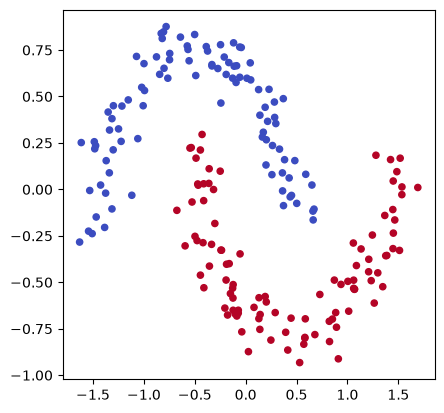

In [33]:
plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)

In [34]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from math import *


In [35]:
# torch.manual_seed(7777)

m, n = X.shape
h = 20  # num. hidden units per layer
k = 1  # num. of output unit


class Model(nn.Module):
    
    def __init__(self):
        super(Model, self).__init__()

        self.feature_map = nn.Sequential(
            nn.Linear(n, h),
            nn.BatchNorm1d(h),
            nn.ReLU(), 
            nn.Linear(h, h), 
            nn.BatchNorm1d(h),
            nn.ReLU()
        )

        self.clf = nn.Linear(h, 1, bias=False)
    
    def forward(self, x):
        x = self.feature_map(x)
        return self.clf(x)
    
    
X_train = X
y_train = Y
    
model = Model()
opt = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

for it in range(5000):
    y_pred = model(X_train).squeeze()
    l = F.binary_cross_entropy_with_logits(y_pred, y_train)
    l.backward()
    opt.step()
    opt.zero_grad()
        
print(f'Loss: {l.item():.3f}')

Loss: 0.005


In [36]:
x1 = torch.linspace(-5, 5, 100)
x2 = torch.linspace(-5, 5, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

X_test = torch.stack((X1.flatten(), X2.flatten()), dim=-1)

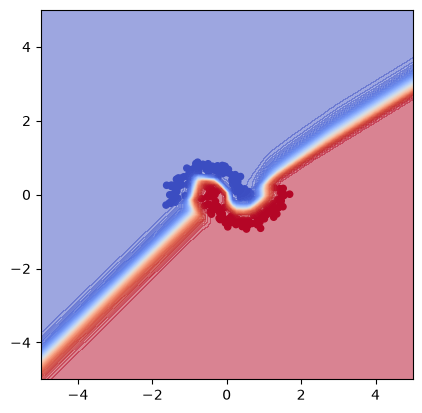

In [37]:
model.eval()

def sigmoid(x):
    return 1/(1+np.exp(-x))

with torch.no_grad():
    model.eval()
    py = sigmoid(model(X_test).squeeze().numpy())
    
conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)

C:\Users\stoennis\AppData\Local\Temp\ipykernel_10364\2433527366.py:56: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)


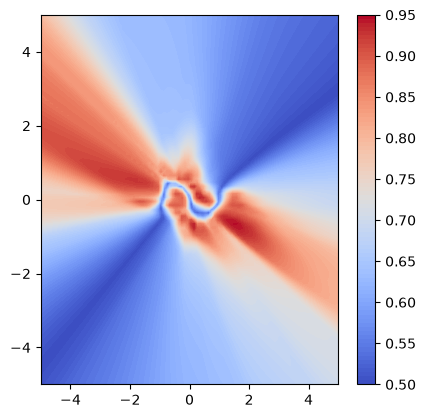

In [38]:
# Exact Hessian using PyTorch's autograd. Credits due to Felix Dangel.
from hessian import exact_hessian


W = list(model.parameters())[-1]
shape_W = W.shape

w_map = W.view(-1).data.numpy()


def neg_log_posterior(var0):
    # Negative-log-likelihood
    nll = F.binary_cross_entropy_with_logits(model(X_train).squeeze(), y_train, reduction='sum')
    # Negative-log-prior
    nlp = 1/2 * W.flatten() @ (1/var0 * torch.eye(W.numel())) @ W.flatten()
    
    return nll + nlp


def get_covariance(var0):
    # Outputs the inverse-Hessian of the negative-log-posterior at the MAP estimate
    # This is the posterior covariance
    loss = neg_log_posterior(var0)
    Lambda = exact_hessian(loss, [W])  # The Hessian of the negative log-posterior
    Sigma = torch.inverse(Lambda).detach().numpy()
    
    return Sigma


@torch.no_grad()
def predict(x, Sigma):    
    phi = model.feature_map(x).numpy()  # Feature vector of x
    m = phi @ w_map  # MAP prediction

    # "Moderate" the MAP prediction using the variance (see MacKay 1992 "Evidence Framework ...")
    # This is an approximation of the expected sigmoid (the so-called "probit approximation")
    v = np.diag(phi @ Sigma @ phi.T)
    py = sigmoid(m/np.sqrt(1 + pi/8 * v))
        
    return py


# The weight decay used for training is the Gaussian prior's precision
# Here we work in term of variance, which is just 1/precision.
var0 = 1/5e-4 

# Get the posterior covariance and make prediction
Sigma = get_covariance(var0)
py = predict(X_test, Sigma)

conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
# plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)
plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()


In [39]:
import math

import pyro

import pyro.distributions as dist
from pyro.infer import SVI, Predictive, Trace_ELBO
from pyro.infer.autoguide import AutoLaplaceApproximation, init_to_value

from dataclasses import dataclass

## Full Pyro model: MLE features + Laplace on the last layer

Everything is trained inside Pyro here. `feature_map` holds plain
`nn.Parameter`s, which `PyroModule` registers in the param store, so SVI fits
them by maximum likelihood; `w` is the only latent site, so
`AutoLaplaceApproximation` puts a Gaussian on the last layer only.

Two things to get right:

* `prior_scale` is a **standard deviation**. The weight decay is the prior
  *precision*, so `prior_scale = sqrt(var0)`, not `var0`.
* `logits = (phi @ w.unsqueeze(-1)).squeeze(-1)` rather than `phi @ w`, so the
  shapes still work when `Predictive` adds a leading sample dimension.

In [40]:
class BayesianMLP(pyro.nn.PyroModule):
    def __init__(self, n, h, prior_scale=1.0):
        super().__init__()
        self.h = h
        self.feature_map = nn.Sequential(
            nn.Linear(n, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
        )
        self.prior_scale = prior_scale
        self._guide = AutoLaplaceApproximation(self.model, init_loc_fn=init_to_value(values={"w": torch.rand(h)*-2*h**-2 + h**-2}))

    def model(self, x, y=None):
        phi = self.feature_map(x)
        w = pyro.sample(
            "w", dist.Normal(torch.zeros(self.h), self.prior_scale).to_event(1)
        )
        logits = (phi @ w.unsqueeze(-1)).squeeze(-1)   # (..., N)
        pyro.deterministic("logits", logits)
        with pyro.plate("data", x.shape[0]):
            pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    def guide(self, x, y=None):
        return self._guide(x, y)

In [41]:
LOG_EVERY = 1000
N_STEPS = 10000

In [ ]:
from pyro.optim import ClippedAdam, SGD

pyro.clear_param_store()
# torch.manual_seed(7777)

N_STEPS = 5000
initial_lr = 1e-3          # 1e-3 leaves this badly undertrained after 10k steps
lrd = 0.1 ** (1 / N_STEPS)
var0 = 1/5e-4                 # prior variance of the last layer weights


BNN = BayesianMLP(n=n, h=h, prior_scale=math.sqrt(var0))   # scale, not variance!
BNN.feature_map.train()                                    # BatchNorm uses batch stats

svi = SVI(
    BNN.model,
    BNN.guide,
    # ClippedAdam({"lr": initial_lr, "lrd": lrd, "eps": 1e-12, "clip_norm": 10.0}),
    SGD({"lr": 1e-3, "momentum": 0.9, "weight_decay": 5e-4}),
    loss=Trace_ELBO(),     # the guide is a Delta, so this is just -log p(w, D)
)


In [43]:

losses = []
for step in range(1, N_STEPS + 1):
    losses.append(svi.step(X_train, y_train))
    if step % LOG_EVERY == 0:
        print(f"    step {step:>6}/{N_STEPS}   -log p(w, D): {losses[-1]:>12.4f}")

    step   1000/5000   -log p(w, D):    2305.9601
    step   2000/5000   -log p(w, D):    2305.4935
    step   3000/5000   -log p(w, D):    2305.3193
    step   4000/5000   -log p(w, D):    2305.2264
    step   5000/5000   -log p(w, D):    2305.1682


In [44]:
store = pyro.get_param_store()
for k in sorted(store.keys()):
    v = store[k]
    print(f"{k:28s} {tuple(v.shape)}  |v| mean {v.abs().mean():.4f}")

_guide.loc                   (20,)  |v| mean 3.1162
feature_map$$$0.bias         (20,)  |v| mean 0.3089
feature_map$$$0.weight       (20, 2)  |v| mean 0.2901
feature_map$$$1.bias         (20,)  |v| mean 0.0000
feature_map$$$1.weight       (20,)  |v| mean 1.0000
feature_map$$$3.bias         (20,)  |v| mean 0.1039
feature_map$$$3.weight       (20, 20)  |v| mean 0.1118
feature_map$$$4.bias         (20,)  |v| mean 0.0000
feature_map$$$4.weight       (20,)  |v| mean 1.0000


Text(0, 0.5, '$-\\log p(w, D)$')

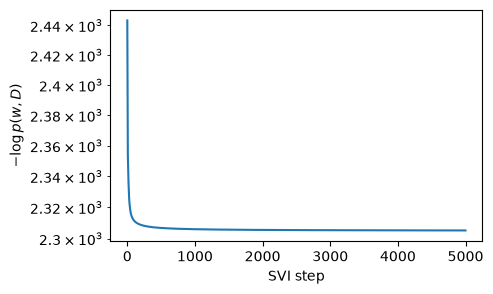

In [45]:
plt.figure(figsize=(4.8, 3))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("SVI step"); plt.ylabel(r"$-\log p(w, D)$")

### Switch BatchNorm to eval mode *before* the Laplace step

This is the bug that made the $[-15,15]^2$ and $[-5,5]^2$ plots identical. In
train mode `BatchNorm1d` normalises by the statistics of *the batch it is
currently given*, so the test grid gets standardised to zero mean / unit
variance whatever its extent — both grids collapse onto the same standardised
inputs and the network cannot tell them apart. `eval()` switches to the running
statistics accumulated during training, which is what makes absolute input
coordinates mean anything at test time.

It also has to happen before `laplace_approximation`, so the Hessian is taken
through the same fixed feature map that prediction will use.

In [46]:
BNN.feature_map.eval()
for p in BNN.feature_map.parameters():
    p.requires_grad_(False)

with torch.no_grad():
    w_hat = pyro.param("_guide.loc")
    acc = (((BNN.feature_map(X_train) @ w_hat) > 0).double() == y_train).double().mean()
print(f"train accuracy: {acc:.3f}")

guide = BNN._guide.laplace_approximation(X_train, y_train)
posterior = guide.get_posterior()
loc, Sigma = posterior.mean, posterior.covariance_matrix
print("posterior std (first 5):", posterior.stddev[:5].numpy().round(3))

train accuracy: 1.000
posterior std (first 5): [63.716 33.652 81.207 23.383 71.319]


In [47]:
print(Sigma)
print(type(Sigma))

tensor([[ 4059.6978,   575.5315, -3171.2195,  -845.9757,   206.2174,  1427.5342,
           215.8238,  -832.1382,   665.5073,   703.9428, -1026.8628,   222.9494,
           162.4358,  -933.9941, -1634.0588, -1687.3682,   680.1357,  -880.8868,
          2335.1197,   -46.9565],
        [  575.5315,  1132.4648,  -215.8108,  -284.0141, -1391.2365,   153.1285,
           153.9796,   870.9302,   -35.7162,   170.5665,  -590.7172,   143.8775,
           305.5082,  -632.4836,  -406.2745,  -206.3988,   -34.1844,   -18.2057,
           446.4562,  -267.7488],
        [-3171.2195,  -215.8108,  6594.5341,   473.0275,  1947.7116, -4607.0851,
          -130.6215, -1141.6447,  -803.7686,   476.8423,  -341.9819,  2118.9222,
           225.6775,  3029.9028,   666.0741,   -14.9856, -1004.4948,  -910.2333,
         -3415.1588,   464.9796],
        [ -845.9757,  -284.0141,   473.0275,   546.7442,   260.3332,  -424.8567,
          -372.1558,   247.3466,   194.8445,  -302.6082,   634.6985,  -312.6468,
       

### Predict on both grids

They should now look clearly different: outside the data the Laplace posterior
pulls the probability back toward 0.5.

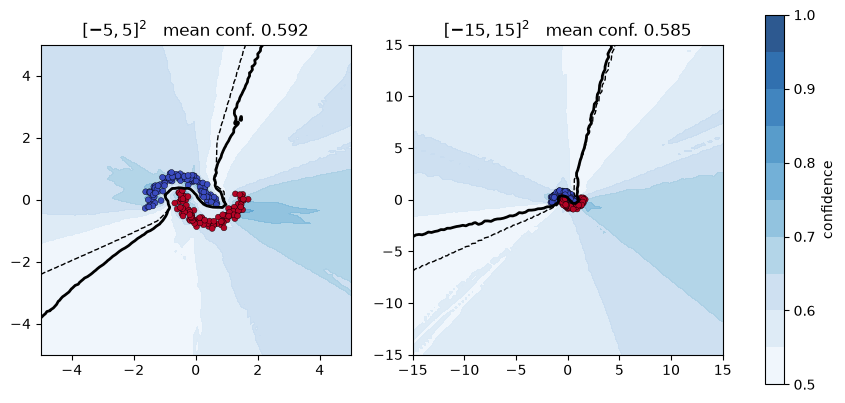

In [48]:
predictive = Predictive(BNN.model, guide=guide, num_samples=1000,
                        return_sites=("logits",))


def grid(lo, hi, N=100):
    t = torch.linspace(lo, hi, N)
    A, B = torch.meshgrid(t, t, indexing="ij")
    return A, B, torch.stack((A.flatten(), B.flatten()), dim=-1)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, (lo, hi) in zip(axes, ((-5, 5), (-15, 15))):
    A, B, Xt = grid(lo, hi)

    p = predictive(Xt, None)["logits"].sigmoid().mean(0).detach().reshape(A.shape)
    with torch.no_grad():
        p_map = (BNN.feature_map(Xt) @ loc).sigmoid().reshape(A.shape)

    conf = torch.maximum(p, 1 - p)
    im = ax.contourf(A, B, conf, levels=np.arange(0.5, 1.01, 0.05),
                     cmap="Blues", vmin=0.5, vmax=1.0, alpha=0.85)
    ax.contour(A, B, p, levels=[0.5], colors="black", linewidths=2)
    ax.contour(A, B, p_map, levels=[0.5], colors="black", linewidths=1,
               linestyles="dashed")
    ax.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=18,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"$[{lo},{hi}]^2$   mean conf. {conf.mean():.3f}")
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="confidence")

In [49]:
X1, X2, X_test = grid(-5, 5)

p = predictive(X_test, None)["logits"].sigmoid().mean(0).detach().reshape(X1.shape)
with torch.no_grad():
    p_map = (BNN.feature_map(X_test) @ loc).sigmoid().reshape(X1.shape)

conf = torch.maximum(p, 1 - p)

phi = BNN.feature_map(X_test).detach().numpy()
m = phi @ loc.detach().numpy()
Lambda = posterior.covariance_matrix.detach().numpy()
Sigma = np.linalg.inv(Lambda)
v = np.diag(phi @ Lambda @ phi.T)
py = sigmoid(m/np.sqrt(1 + pi/8 * v))
p_map_ll = py
conf_map = np.maximum(p_map_ll, 1 - p_map_ll)


C:\Users\stoennis\AppData\Local\Temp\ipykernel_10364\303920402.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf, levels=100, cmap='coolwarm', linewidths=2)


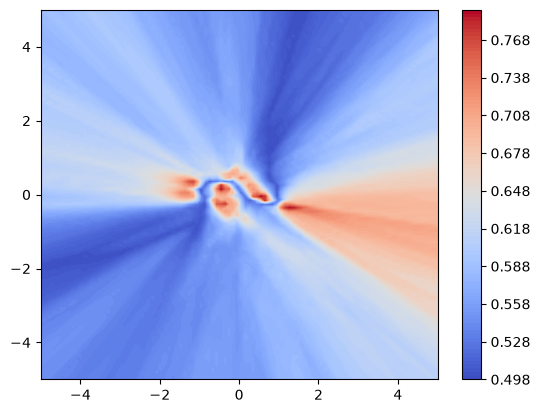

In [50]:


# plt.contourf(X1, X2, p, levels=100, cmap='coolwarm', linewidths=2)
plt.contourf(X1, X2, conf, levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()

C:\Users\stoennis\AppData\Local\Temp\ipykernel_10364\203417728.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf_map.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)


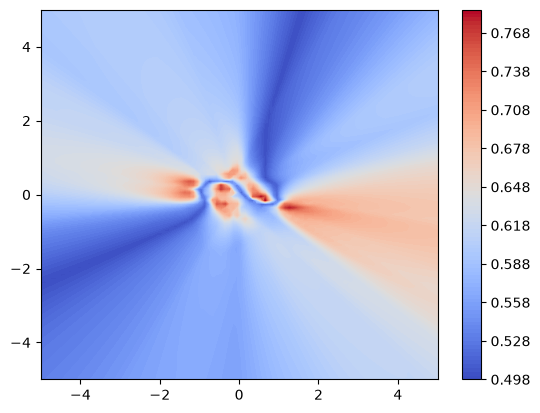

In [51]:

# plt.contourf(X1, X2, p, levels=100, cmap='coolwarm', linewidths=2)
plt.contourf(X1, X2, conf_map.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()

In [52]:
from pyro.infer import MCMC, NUTS


BNN.feature_map.eval()                       # BatchNorm -> running stats
for p in BNN.feature_map.parameters():
    p.requires_grad_(False)                  # also drops them from the param store

w_map = pyro.param("_guide.loc").detach().clone()
kernel = NUTS(BNN.model, init_strategy=init_to_value(values={"w": w_map}))

mcmc = MCMC(
    kernel=kernel,
    num_chains=5,
    num_samples=1500,
    warmup_steps=500,
    mp_context="spawn"
)
mcmc.run(X_train,y_train)

Warmup [1]:   0%|          | 0/2000 [00:00, ?it/s]







Warmup [5]:   0%|          | 0/2000 [05:17, ?it/s]


KeyboardInterrupt: 

In [23]:
mcmc.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      w[0]  11895.96  17490.52  13695.79 -17805.26  37766.52      5.16      1.26
      w[1] -61797.05  48647.53 -51416.60 -119603.64  10160.63      2.89      2.89
      w[2]  -3382.10  19945.48  -3246.43 -23071.82  36063.88     20.14      1.00
      w[3]  49641.55  24405.31  46701.10   4776.34  83558.44      9.46      1.23
      w[4] -53372.67  19238.49 -53769.25 -78610.35 -16939.32      5.32      1.36
      w[5]   3534.48  44926.39   8782.78 -29732.96  62364.57     13.21      1.03
      w[6]  43912.16  72555.83   9196.99 -37031.36 142941.63      2.50      3.11
      w[7] -13526.41  33699.01  -6380.93 -71442.78  29513.44      6.63      1.22
      w[8]  20446.54  12512.20  20947.25   1548.82  35836.51      3.46      1.63
      w[9]  14919.70  24561.35  11027.05 -18767.43  53715.24      3.10      2.10
     w[10]  39449.84  15183.20  34578.96  18585.86  60943.11      3.48      2.19
     w[11]  73116.31  3958

In [24]:
samples = mcmc.get_samples(num_samples=1500)

In [25]:
mcmc_predictive = Predictive(model=BNN.model,posterior_samples=samples)

In [26]:
X1, X2, X_test = grid(-5, 5)

p = mcmc_predictive(X_test, None)["logits"].sigmoid().mean(0).detach().reshape(X1.shape)
# with torch.no_grad():
#     p_map = (BNN.feature_map(X_test) @ loc).sigmoid().reshape(X1.shape)

conf = torch.maximum(p, 1 - p)

# phi = BNN.feature_map(X_test).detach().numpy()
# m = phi @ loc.detach().numpy()
# Lambda = posterior.covariance_matrix.detach().numpy()
# Sigma = np.linalg.inv(Lambda)
# v = np.diag(phi @ Lambda @ phi.T)
# py = sigmoid(m/np.sqrt(1 + pi/8 * v))
# p_map_ll = py
# conf_map = np.maximum(p_map_ll, 1 - p_map_ll)


C:\Users\stoennis\AppData\Local\Temp\ipykernel_10364\270340187.py:1: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf, levels=100, cmap='coolwarm', linewidths=2)


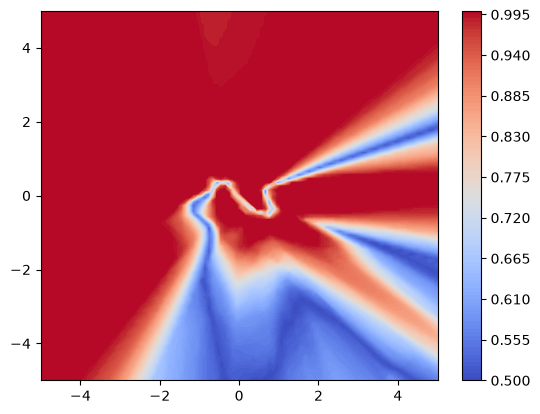

In [27]:
plt.contourf(X1, X2, conf, levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()